## Imports

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, average_precision_score
from sklearn.utils.class_weight import compute_sample_weight

## Load the feature engineered dataset

In [2]:
df = pd.read_csv("../data/lag_feature_dataset.csv")
df.head()
df.columns

Index(['timestamp', 'server_id', 'server_type', 'cpu_percent',
       'memory_percent', 'disk_io', 'is_anomaly', 'is_predictive_anomaly',
       'anomaly_type', 'hour', 'day_of_week', 'cpu_percent_lag_5m',
       'cpu_percent_lag_15m', 'cpu_percent_lag_30m', 'cpu_percent_lag_60m',
       'memory_percent_lag_5m', 'memory_percent_lag_15m',
       'memory_percent_lag_30m', 'memory_percent_lag_60m', 'disk_io_lag_5m',
       'disk_io_lag_15m', 'disk_io_lag_30m', 'disk_io_lag_60m',
       'cpu_percent_5m_change', 'cpu_percent_15m_change',
       'cpu_percent_30m_change', 'memory_percent_5m_change',
       'memory_percent_15m_change', 'memory_percent_30m_change',
       'disk_io_5m_change', 'disk_io_15m_change', 'disk_io_30m_change',
       'target_20m'],
      dtype='str')

## Split dataset into train and test
70/15/15 split, the dataset runs from the 1st Jan to the 21th Jan so I will split the dataet into:
- train: 70%
- validation: 70%
- test: 15%

In [3]:
print(
    df.groupby(["server_id", "server_type"])["is_anomaly"]
      .sum()
      .sort_values(ascending=False)
)

server_id        server_type  
batch_worker_3   batch_worker     39
database_2       database         33
web_3            web              29
web_2            web              28
load_balancer_1  load_balancer    23
cache_3          cache            22
load_balancer_2  load_balancer    21
database_3       database         20
cache_2          cache            19
cache_1          cache            16
database_1       database         16
batch_worker_2   batch_worker     14
batch_worker_1   batch_worker      9
web_1            web               8
load_balancer_3  load_balancer     7
Name: is_anomaly, dtype: int64


In [4]:
train_df = df[df['timestamp'] < "2025-01-15 00:00:00"]
validation_df = df[(df['timestamp'] >= "2025-01-15 00:00:00") & (df['timestamp'] < "2025-01-18 00:00:00")]
test_df = df[(df['timestamp'] >= "2025-01-18 00:00:00") & (df['timestamp'] < "2025-01-21 00:00:00")]

In [5]:
print(train_df.shape)
print(f'Anomalies in train_df: {train_df["is_anomaly"].sum()}')
print(f'Predictive anomalies in train_df: {train_df["is_predictive_anomaly"].sum()}')

(60300, 33)
Anomalies in train_df: 212
Predictive anomalies in train_df: 279


In [6]:
print(validation_df.shape)
print(f'Anomalies in validation_df: {validation_df["is_anomaly"].sum()}')
print(f'Predictive anomalies in validation_df: {validation_df["is_predictive_anomaly"].sum()}')

(12960, 33)
Anomalies in validation_df: 33
Predictive anomalies in validation_df: 60


In [7]:
print(test_df.shape)
print(f'Anomalies in test_df: {test_df["is_anomaly"].sum()}')
print(f'Predictive anomalies in test_df: {test_df["is_predictive_anomaly"].sum()}')

(12960, 33)
Anomalies in test_df: 37
Predictive anomalies in test_df: 64


### Split into x and y train, validate and test sets

In [8]:
drop_colmuns = [
    "is_anomaly",
    "is_predictive_anomaly",
    "server_id",
    "timestamp",
    "anomaly_type",
    "target_20m"
]

In [9]:
y_train = train_df["target_20m"]
X_train = train_df.drop(columns=drop_colmuns)

print(f'y_train shape:{y_train.shape}')
print(f'X_train columns:{X_train.columns}')

y_train shape:(60300,)
X_train columns:Index(['server_type', 'cpu_percent', 'memory_percent', 'disk_io', 'hour',
       'day_of_week', 'cpu_percent_lag_5m', 'cpu_percent_lag_15m',
       'cpu_percent_lag_30m', 'cpu_percent_lag_60m', 'memory_percent_lag_5m',
       'memory_percent_lag_15m', 'memory_percent_lag_30m',
       'memory_percent_lag_60m', 'disk_io_lag_5m', 'disk_io_lag_15m',
       'disk_io_lag_30m', 'disk_io_lag_60m', 'cpu_percent_5m_change',
       'cpu_percent_15m_change', 'cpu_percent_30m_change',
       'memory_percent_5m_change', 'memory_percent_15m_change',
       'memory_percent_30m_change', 'disk_io_5m_change', 'disk_io_15m_change',
       'disk_io_30m_change'],
      dtype='str')


In [10]:
y_val = validation_df["target_20m"]
X_val = validation_df.drop(columns=drop_colmuns)

print(f'y_val shape:{y_train.shape}')
print(f'X_val columns:{X_train.columns}')

y_val shape:(60300,)
X_val columns:Index(['server_type', 'cpu_percent', 'memory_percent', 'disk_io', 'hour',
       'day_of_week', 'cpu_percent_lag_5m', 'cpu_percent_lag_15m',
       'cpu_percent_lag_30m', 'cpu_percent_lag_60m', 'memory_percent_lag_5m',
       'memory_percent_lag_15m', 'memory_percent_lag_30m',
       'memory_percent_lag_60m', 'disk_io_lag_5m', 'disk_io_lag_15m',
       'disk_io_lag_30m', 'disk_io_lag_60m', 'cpu_percent_5m_change',
       'cpu_percent_15m_change', 'cpu_percent_30m_change',
       'memory_percent_5m_change', 'memory_percent_15m_change',
       'memory_percent_30m_change', 'disk_io_5m_change', 'disk_io_15m_change',
       'disk_io_30m_change'],
      dtype='str')


In [11]:
y_test = test_df["target_20m"]
X_test = test_df.drop(columns=drop_colmuns)

print(f'y_test shape:{y_val.shape}')
print(f'X_test columns:{X_val.columns}')

y_test shape:(12960,)
X_test columns:Index(['server_type', 'cpu_percent', 'memory_percent', 'disk_io', 'hour',
       'day_of_week', 'cpu_percent_lag_5m', 'cpu_percent_lag_15m',
       'cpu_percent_lag_30m', 'cpu_percent_lag_60m', 'memory_percent_lag_5m',
       'memory_percent_lag_15m', 'memory_percent_lag_30m',
       'memory_percent_lag_60m', 'disk_io_lag_5m', 'disk_io_lag_15m',
       'disk_io_lag_30m', 'disk_io_lag_60m', 'cpu_percent_5m_change',
       'cpu_percent_15m_change', 'cpu_percent_30m_change',
       'memory_percent_5m_change', 'memory_percent_15m_change',
       'memory_percent_30m_change', 'disk_io_5m_change', 'disk_io_15m_change',
       'disk_io_30m_change'],
      dtype='str')


### One hot encoding of server type
The model should learn using server_type, its unable to read 'web','database' ... so we encode this.

- `encoder.fit` is only used on the training dataset, as we only want the model to learn from server type during trainig and not validation or testing

In [12]:
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

encoder.fit(X_train[["server_type"]])

server_type_train = encoder.transform(X_train[["server_type"]])
server_type_val = encoder.transform(X_val[["server_type"]])
server_type_test = encoder.transform(X_test[["server_type"]])

In [13]:
X_train = X_train.drop(columns="server_type")
X_test = X_test.drop(columns="server_type")
X_val = X_val.drop(columns="server_type")
print(f'X_test columns:{X_val.columns}')

X_test columns:Index(['cpu_percent', 'memory_percent', 'disk_io', 'hour', 'day_of_week',
       'cpu_percent_lag_5m', 'cpu_percent_lag_15m', 'cpu_percent_lag_30m',
       'cpu_percent_lag_60m', 'memory_percent_lag_5m',
       'memory_percent_lag_15m', 'memory_percent_lag_30m',
       'memory_percent_lag_60m', 'disk_io_lag_5m', 'disk_io_lag_15m',
       'disk_io_lag_30m', 'disk_io_lag_60m', 'cpu_percent_5m_change',
       'cpu_percent_15m_change', 'cpu_percent_30m_change',
       'memory_percent_5m_change', 'memory_percent_15m_change',
       'memory_percent_30m_change', 'disk_io_5m_change', 'disk_io_15m_change',
       'disk_io_30m_change'],
      dtype='str')


## Train XGBoost model

- **Round 1**: lag features 
- **Round 2**: lag features + trend features
- **Round 3**: lag features + rolling windows
- **Round 4**: lag features + trend features + rolling windows

Findings:
The precision, recall and f1 score are for the model detcting if an anomaly is set in the next 30 m

|Round    | Precision | Recall | F1 score |
|-------  | ---------:| ------:| ---------|
| 1       | 0.14      | 0.34   | 0.20     |
| 2       | 0.30      | 0.47   | 0.37     |
| 3       | 0.28      | 0.29   | 0.29     |
| 4       | 0.39      | 0.46   | 0.42     |

After discovering the target features were 1.0 for anomalies aswell, I changed it so that it labels rows where an anomaly happens in the next 30m but the target feature doesn't include anomalies themselves. And I re trained the models.

|Round    | Precision | Recall | F1 score | PR-AUC | scale_pos_weight| sample_weights|
|-------  | ---------:| ------:| ---------| -------| ----------------|----------------
| 1       | 0.02      | 0.14   | 0.04     |
| 2       | 0.12      | 0.29   | 0.17     | 0.187  | No              | yes
| 2       | 0.13      | 0.33   | 0.20     | 0.187  | Yes             | No
| 4       | 0.13      | 0.17   | 0.15     |

- Now there are less values for the model to learn from it is struggling more to predict anomalies

I changed the target feature to detect anomalies 20 minutes ahead instead of 30

|Round    | Precision | Recall | F1 score | PR-AUC | scale_pos_weight| sample_weights|
|-------  | ---------:| ------:| ---------| -------| ----------------|----------------
| 2       | 0.50      | 0.46   | 0.48     | 0.233  | No              | yes



### Round 1
- XGBoost seems to be using the raw values more
>   ```text
>   memory_percent            0.103077
>   cpu_percent               0.094161
>   disk_io                   0.087033
>   disk_io_lag_60m           0.074256
>   hour                      0.073782
>   day_of_week               0.071393
>   cpu_percent_lag_60m       0.067703
>   disk_io_lag_15m           0.063376
>   cpu_percent_lag_5m        0.061267
>   disk_io_lag_5m            0.049827
>   disk_io_lag_30m           0.046681
>   cpu_percent_lag_30m       0.044402
>   memory_percent_lag_60m    0.039004
>   memory_percent_lag_5m     0.034442
>   cpu_percent_lag_15m       0.033868
>   memory_percent_lag_15m    0.028993
>   memory_percent_lag_30m    0.026736
>   ```

### Round 2
- The model prioritises the change features over the raw features
>   ```text
>   disk_io_30m_change           0.105866
>   memory_percent_30m_change    0.094719
>   cpu_percent_30m_change       0.087065
>   memory_percent               0.075579
>   cpu_percent_lag_60m          0.059068
>   cpu_percent                  0.053123
>   cpu_percent_lag_5m           0.042822
>   cpu_percent_lag_15m          0.038197
>   hour                         0.037521
>   day_of_week                  0.037174
>   disk_io_lag_60m              0.032998
>   disk_io                      0.032384
>   disk_io_lag_15m              0.032084
>   disk_io_lag_30m              0.028937
>   cpu_percent_lag_30m          0.028596
>   disk_io_lag_5m               0.028267
>   memory_percent_15m_change    0.023426
>   memory_percent_lag_5m        0.021571
>   memory_percent_lag_15m       0.021235
>   disk_io_5m_change            0.020284
>   ```
- The model is struggling to predict weaker anomalies, the change features might not be representitive enough of the weaker anomalies
- The model was able to detect extreme anomalies, learning something moves dramatically away from normal == anomaly.

### Round 3
- The model prioritises the rolling std's
>   ```text
>   disk_io_roll_standard_deviation_30           0.086809
>   memory_percent_roll_standard_deviation_30    0.079544
>   memory_percent                               0.065417
>   cpu_percent_roll_standard_deviation_30       0.057700
>   cpu_percent                                  0.051361
>   cpu_percent_lag_60m                          0.049759
>   cpu_percent_roll_mean_15                     0.046678
>   disk_io_roll_mean_30                         0.041227
>   disk_io_roll_mean_15                         0.036909
>   memory_percent_roll_mean_15                  0.036685
>   hour                                         0.035881
>   disk_io                                      0.034739
>   cpu_percent_roll_mean_30                     0.033187
>   day_of_week                                  0.032617
>   memory_percent_roll_mean_30                  0.031797
>   disk_io_roll_standard_deviation_15           0.027296
>   disk_io_lag_60m                              0.023025
>   disk_io_lag_30m                              0.022820
>   disk_io_lag_5m                               0.022646
>   memory_percent_roll_standard_deviation_15    0.022543
>   ```
- The model peformed worse compared to model trained with other features, the precision is almost the same **28%** compared to **30%**. However its not predicting the anomalies as well as when the model was trained with the trend features, recall; **47%** vs **29%**. So the model is predicting anomalies, however isn't picking up on as many compared the round 2' model

#### Handling the highly unbalanced data
`scale_pos_weight`
$$scale\_pos\_weight = \frac{\text{Total Negative Instances}}{\text{Total Positive Instances}}$$

`sample weights`
$$w_c = \frac{n_{\text{samples}}}{n_{\text{classes}} \cdot \text{np.bincount}(y)_c}$$


useful resource: https://medium.com/@mate.voros1998/handling-imbalanced-datasets-with-xgboost-optimizing-model-performance-with-smart-parameter-tuning-18568c7783cf

In [14]:
# to handle the highly unbalanced data
scale_pos_weight = sum(y_train == 0) / sum(y_train == 1)

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
print(sample_weights)

[0.50143028 0.50143028 0.50143028 ... 0.50143028 0.50143028 0.50143028]


In [15]:
xgb_model = xgb.XGBClassifier(
    random_state=42, 
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,

)

In [16]:
xgb_model.fit(X_train, y_train, sample_weight=sample_weights)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


### Make predictions using the validation data

In [17]:
y_val_pred = xgb_model.predict(X_val)

In [18]:
cm = classification_report(y_val,y_val_pred)
print(cm)

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     12932
         1.0       0.50      0.46      0.48        28

    accuracy                           1.00     12960
   macro avg       0.75      0.73      0.74     12960
weighted avg       1.00      1.00      1.00     12960



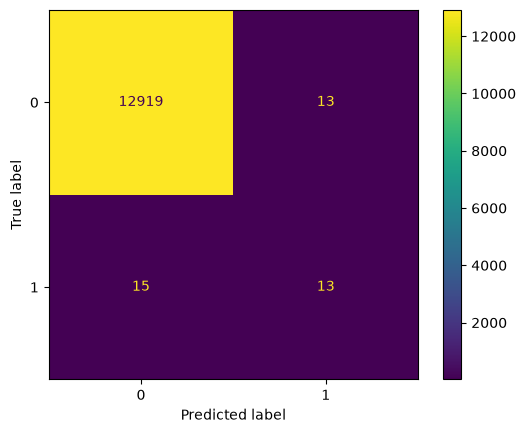

In [19]:
cm = confusion_matrix(y_val,y_val_pred)

display_cm = ConfusionMatrixDisplay(confusion_matrix=cm)
display_cm.plot()

plt.show()

In [20]:
pr_auc = average_precision_score(y_val, y_val_pred)

print(f"PR-AUC: {pr_auc:.3f}")

PR-AUC: 0.233


### Diagnosing the low Precison, Recall and F1 score

The model is unable to detect any anomalies, below are the probabilities that the model thinks an anomaly will happen in the next 30 mins.


In [21]:
y_val_prob = xgb_model.predict_proba(X_val)[:, 1] # generates a probability that each validation row belongs to class 1 (anomaly in next 30m)

print(y_val_prob.max())
print(y_val_prob.mean())
print(y_val_prob[y_val == 1])

0.98987716
0.027301144
[0.13427942 0.01194922 0.52735263 0.7869801  0.01411414 0.04518082
 0.02807886 0.9397514  0.63101995 0.80239093 0.1726166  0.12117498
 0.5076974  0.9891557  0.98987716 0.9734789  0.7933216  0.8283524
 0.6712513  0.15772815 0.11903141 0.09526452 0.3714623  0.2024296
 0.37182966 0.5684911  0.25076813 0.04404133]


In [22]:
normal_probs = y_val_prob[y_val == 0] # anomaly will not happen in the next 30 mins
anomaly_probs = y_val_prob[y_val == 1]

print("Normal mean:", normal_probs.mean())
print("Anomaly mean:", anomaly_probs.mean())

print("Normal max:", normal_probs.max())
print("Anomaly max:", anomaly_probs.max())

print("Anomaly probabilities:")
print(anomaly_probs)

Normal mean: 0.026420796
Anomaly mean: 0.43389535
Normal max: 0.9870139
Anomaly max: 0.98987716
Anomaly probabilities:
[0.13427942 0.01194922 0.52735263 0.7869801  0.01411414 0.04518082
 0.02807886 0.9397514  0.63101995 0.80239093 0.1726166  0.12117498
 0.5076974  0.9891557  0.98987716 0.9734789  0.7933216  0.8283524
 0.6712513  0.15772815 0.11903141 0.09526452 0.3714623  0.2024296
 0.37182966 0.5684911  0.25076813 0.04404133]


In [23]:
importance = pd.Series(
    xgb_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importance.head(20))

memory_percent_30m_change    0.109398
cpu_percent_30m_change       0.108793
disk_io_15m_change           0.097301
cpu_percent_lag_60m          0.063607
disk_io_30m_change           0.054024
hour                         0.050823
memory_percent               0.046957
disk_io_lag_15m              0.044923
day_of_week                  0.042736
memory_percent_15m_change    0.042276
cpu_percent                  0.039745
cpu_percent_15m_change       0.035226
disk_io_lag_60m              0.034447
disk_io                      0.030239
cpu_percent_lag_30m          0.028200
memory_percent_lag_60m       0.023912
cpu_percent_lag_5m           0.021666
disk_io_lag_30m              0.021562
disk_io_lag_5m               0.021392
memory_percent_lag_5m        0.016476
dtype: float32


In [24]:
positive_probs = y_val_prob[y_val == 1]

print("Number of actual predictions:", len(positive_probs))
print("Mean probability:", positive_probs.mean())
print("Minimum probability:", positive_probs.min())
print("Maximum probability:", positive_probs.max())

Number of actual predictions: 28
Mean probability: 0.43389535
Minimum probability: 0.011949219
Maximum probability: 0.98987716


In [25]:
pd.set_option("display.max_rows", None)
validation_df["probability"] = y_val_prob

positive_validation = validation_df[
    validation_df["target_20m"] == 1
]


positive_validation.sort_values("probability")


,timestamp,server_id,server_type,cpu_percent,memory_percent,disk_io,is_anomaly,is_predictive_anomaly,anomaly_type,hour,...,cpu_percent_15m_change,cpu_percent_30m_change,memory_percent_5m_change,memory_percent_15m_change,memory_percent_30m_change,disk_io_5m_change,disk_io_15m_change,disk_io_30m_change,target_20m,probability
10770,2025-01-17 11:50:00,web_2,web,23.607889,53.586665,113.117161,0,1,predictive_cpu_percent_drop,11,...,-30.093736,-34.544310,4.499544,3.109717,-4.236055,4.340421,5.312146,3.951367,1.0,0.011949
16543,2025-01-16 14:15:00,web_3,web,52.230754,53.275949,111.621135,0,0,normal,14,...,-3.213998,5.282998,-2.625054,-0.708405,-0.064298,4.893079,-0.120823,-2.168529,1.0,0.014114
16545,2025-01-16 14:25:00,web_3,web,51.548819,53.833195,106.990142,0,1,predictive_disk_io_spike,14,...,-5.567129,4.910297,2.838546,-2.067809,-6.352038,5.323688,0.262086,-6.056965,1.0,0.028079
88889,2025-01-16 11:05:00,batch_worker_3,batch_worker,9.273465,47.778420,18.481290,0,1,predictive_memory_percent_spike,11,...,-1.148412,1.586162,1.213000,5.810037,16.502715,0.758422,-1.079770,-1.703668,1.0,0.044041
16544,2025-01-16 14:20:00,web_3,web,53.275271,50.994649,101.666454,0,0,normal,14,...,0.253382,1.366226,-2.281300,-4.570249,0.154935,-9.954681,-3.827021,-7.725317,1.0,0.045181
64363,2025-01-15 01:55:00,load_balancer_2,load_balancer,28.406244,73.396197,19.954279,0,1,predictive_memory_percent_spike,1,...,-1.769573,-2.304622,5.779905,20.156742,39.491144,3.193032,-1.387191,-10.241981,1.0,0.095265
64362,2025-01-15 01:50:00,load_balancer_2,load_balancer,31.738254,67.616292,16.761247,0,1,predictive_memory_percent_spike,1,...,8.488900,-2.484770,6.774752,21.566742,37.337508,-2.381845,-1.933699,-3.330742,1.0,0.119031
16862,2025-01-17 16:50:00,web_3,web,48.828959,73.736205,84.885712,0,1,predictive_memory_percent_spike,16,...,4.147288,1.141580,0.717155,4.056440,14.729555,-5.629184,-3.379737,-6.105592,1.0,0.121175
10769,2025-01-17 11:45:00,web_2,web,33.420494,49.087121,108.776739,0,1,predictive_cpu_percent_drop,11,...,-26.876180,-23.010239,-5.813617,-6.495404,-5.868983,4.442706,-6.868225,1.636804,1.0,0.134279
53132,2025-01-17 23:20:00,cache_3,cache,13.758324,80.243754,20.314100,0,1,predictive_memory_percent_spike,23,...,-0.799100,-1.578702,0.719681,7.277401,18.955626,-4.788013,-2.387756,-0.783183,1.0,0.157728


### Test: does the model give atleast one alert before an anomaly

The model alerted 6/7 anomalies, which is a **85.7%** detection rate. The time before the anomaly alerts range from 5-20 minutes 

In [26]:
threshold = 0.5

validation_df["alert"] = (
    validation_df["probability"] >= threshold
).astype(int)

In [27]:
validation_df = validation_df.sort_values(
    ["server_id", "timestamp"]
).copy()

validation_df["anomaly_start"] = (
    (validation_df["is_anomaly"] == 1) &
    (validation_df.groupby("server_id")["is_anomaly"]
        .shift(1)
        .fillna(0)
        .eq(0))
)

In [28]:
validation_df[
    validation_df["anomaly_start"]
][["server_id", "timestamp"]]

,server_id,timestamp
88890,batch_worker_3,2025-01-16 11:10:00
40516,cache_1,2025-01-16 01:20:00
53133,cache_3,2025-01-17 23:25:00
64366,load_balancer_2,2025-01-15 02:10:00
10773,web_2,2025-01-17 12:05:00
16547,web_3,2025-01-16 14:35:00
16863,web_3,2025-01-17 16:55:00


In [29]:
server = "batch_worker_3"

example = validation_df[
    (validation_df["server_id"] == server) &
    (validation_df["timestamp"] >= "2025-01-16 10:50:00" ) &
    (validation_df["timestamp"] <= "2025-01-16 11:10:00")
]

example[
    ["timestamp", "is_anomaly", "is_predictive_anomaly",
     "probability", "anomaly_start", "alert"]
]

,timestamp,is_anomaly,is_predictive_anomaly,probability,anomaly_start,alert
88886,2025-01-16 10:50:00,0,1,0.371830,False,0
88887,2025-01-16 10:55:00,0,1,0.568491,False,1
88888,2025-01-16 11:00:00,0,1,0.250768,False,0
88889,2025-01-16 11:05:00,0,1,0.044041,False,0
88890,2025-01-16 11:10:00,1,0,0.026903,True,0


In [30]:
def check_alert(df):
    df["anomaly_start"] = (
        (df["is_anomaly"] == 1) &
        (df.groupby("server_id")["is_anomaly"]
            .shift(1)
            .fillna(0)
            .eq(0))
    )
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    anomalies = df[df["anomaly_start"]]
    results = []
    for _, anomaly in anomalies.iterrows():
        anomaly_time = anomaly["timestamp"]
        server_id = anomaly["server_id"]
        
        # from anomaly start to 20mins prev is there an alert 
        predicitve_twenty_mins_before = anomaly_time - pd.Timedelta(minutes=20)
    
        # check for rows with alert set to 1
        window = df[
            (df["server_id"] == server_id) &
            (df["timestamp"].between(predicitve_twenty_mins_before,anomaly_time))
            ]

        detected = window["alert"].any()
    
        if detected:
            # time of detection & how long before the anomaly
            first_alert = window.loc[window["alert"] == 1, "timestamp"].iloc[0]
            time_before_anomaly = (anomaly_time - first_alert).total_seconds() / 60
        else:
            first_alert = pd.NaT
            time_before_anomaly= None
            
        results.append({
            "sever_id": server_id,
            "anomaly_start": anomaly_time,
            "detected":detected,
            "first_alert": first_alert,
            "time_alerted_before_anomaly": time_before_anomaly
        })

    return pd.DataFrame(results)

In [31]:
results = check_alert(validation_df)

print(results)

          sever_id       anomaly_start  detected         first_alert  \
0   batch_worker_3 2025-01-16 11:10:00      True 2025-01-16 10:55:00   
1          cache_1 2025-01-16 01:20:00      True 2025-01-16 01:00:00   
2          cache_3 2025-01-17 23:25:00      True 2025-01-17 23:05:00   
3  load_balancer_2 2025-01-15 02:10:00     False                 NaT   
4            web_2 2025-01-17 12:05:00      True 2025-01-17 11:55:00   
5            web_3 2025-01-16 14:35:00      True 2025-01-16 14:30:00   
6            web_3 2025-01-17 16:55:00      True 2025-01-17 16:35:00   

   time_alerted_before_anomaly  
0                         15.0  
1                         20.0  
2                         20.0  
3                          NaN  
4                         10.0  
5                          5.0  
6                         20.0  


### Need to check for fals positive rate

Below we can see that the model fasley alerts anomalies for `database_1`,`database_2`,`database_3`, around the same time too, '2025-01-16 21:40:00' - '2025-01-16 21:45:00'. This could potentially mean the model is learning a normal workd day pattern but thinks it is an anomaly

In [32]:
validation_df[(validation_df["alert"] == 1)][["server_id", "server_type", "timestamp", "is_anomaly","is_predictive_anomaly", "alert"]]

,server_id,server_type,timestamp,is_anomaly,is_predictive_anomaly,alert
76649,batch_worker_1,batch_worker,2025-01-15 20:25:00,0,0,1
82985,batch_worker_2,batch_worker,2025-01-16 21:45:00,0,0,1
88725,batch_worker_3,batch_worker,2025-01-15 21:25:00,0,0,1
88887,batch_worker_3,batch_worker,2025-01-16 10:55:00,0,1,1
88902,batch_worker_3,batch_worker,2025-01-16 12:10:00,0,0,1
40512,cache_1,cache,2025-01-16 01:00:00,0,1,1
40513,cache_1,cache,2025-01-16 01:05:00,0,1,1
40514,cache_1,cache,2025-01-16 01:10:00,0,1,1
40515,cache_1,cache,2025-01-16 01:15:00,0,1,1
40516,cache_1,cache,2025-01-16 01:20:00,1,0,1


In [33]:
def check_false_positives(df):
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    # all the "alerts" check the window from this aler to 20 mins ahead and see if there is an anomaly, if not then its a false positive 
    alerts = df[df["alert"] == 1]
    results = []

    # group the alerts for each server type 
    alerts = alerts.sort_values(["server_id", "timestamp"])

    alerts["previous_alert"] = (
        alerts.groupby("server_id")["timestamp"].shift(1)
    )
    alerts["gap_minutes"] = (
        alerts["timestamp"] - alerts["previous_alert"]
    ).dt.total_seconds() / 60

    alerts["new_episode"] = (
        alerts["previous_alert"].isna() |
        (alerts["gap_minutes"] > 5)
    )

    alerts["episode_id"] = (
        alerts.groupby("server_id")["new_episode"].cumsum()
    )
    episodes = (
        alerts[alerts["new_episode"]]
        .copy()
    )
    
    for _,alert in episodes.iterrows():
        alert_time = alert["timestamp"]
        server_id = alert["server_id"]

        is_anomaly_time = alert_time + pd.Timedelta(minutes=20)

        # find the alert for each server
        window = df[
            (df["timestamp"] > alert_time) &
            (df["timestamp"] <= is_anomaly_time) &
            (df["server_id"] == server_id)
        ]

        anomaly_rows = window[window["is_anomaly"]== 1]

        if not anomaly_rows.empty:
            first_anomaly = anomaly_rows["timestamp"].iloc[0]

            results.append({
                "server_id": server_id,
                "alert_time": alert_time,
                "result": "Useful warning",
                "anomaly_time": first_anomaly,
                "lead_time_minutes": (
                    first_anomaly - alert_time
                ).total_seconds() / 60
            })
        else:
            results.append({
                "server_id": server_id,
                "alert_time": alert_time,
                "result": "False warning",
                "anomaly_time": pd.NaT,
                "lead_time_minutes": None
            })
            
    return pd.DataFrame(results)
 

In [34]:
results = check_false_positives(validation_df)

print(results)

          server_id          alert_time          result        anomaly_time  \
0    batch_worker_1 2025-01-15 20:25:00   False warning                 NaT   
1    batch_worker_2 2025-01-16 21:45:00   False warning                 NaT   
2    batch_worker_3 2025-01-15 21:25:00   False warning                 NaT   
3    batch_worker_3 2025-01-16 10:55:00  Useful warning 2025-01-16 11:10:00   
4    batch_worker_3 2025-01-16 12:10:00   False warning                 NaT   
5           cache_1 2025-01-16 01:00:00  Useful warning 2025-01-16 01:20:00   
6           cache_3 2025-01-15 09:55:00   False warning                 NaT   
7           cache_3 2025-01-17 23:05:00  Useful warning 2025-01-17 23:25:00   
8        database_1 2025-01-16 21:40:00   False warning                 NaT   
9        database_2 2025-01-16 21:45:00   False warning                 NaT   
10       database_3 2025-01-15 21:40:00   False warning                 NaT   
11       database_3 2025-01-16 07:00:00   False warn

In [35]:
print("Total alert episodes:", len(results))

useful = results[results["result"] == "Useful warning"]

print("Useful warning episodes:", len(useful))
print("False warning episodes:", len(results) - len(useful))

print("Warning precision:", len(useful) / len(results))

print("Mean lead time:", useful["lead_time_minutes"].mean())
print("Median lead time:", useful["lead_time_minutes"].median())

Total alert episodes: 18
Useful warning episodes: 6
False warning episodes: 12
Warning precision: 0.3333333333333333
Mean lead time: 15.0
Median lead time: 17.5


## Hetrogenity